The code needs to
1. Implement different dark energy equation of state models
2. Calculate H(z) for these models
3. Solve for the growth of matter perturbations
4. Compute the growth index γ
5. Perform an MCMC analysis to sample possible parameter values

In [1]:
import numpy as np
import emcee
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd
import corner

# Constants and redshift array
c = 299792.4582
H0 = 67.36

In [2]:
cflya_file = "../Documents/cf_lya_x_lya_exp.fits"
#dmatlya_file = "/content/drive/MyDrive/DESI_LSS_DATA/dmat_lya_x_lya.fits"
covariance_file = "../Documents/full-covariance-smoothed.fits"
with fits.open(cflya_file) as hdul:
  # .info() gives overview of file structure
  hdul.info()

  # This prints the contents of the primary HDU ()
  print(hdul[0].header)

  data = hdul[1].data
  xi = data["DA"]
  r_parallel = data["RP"]
  r_transverse = data["RT"]
  redshift = data["Z"]

r = np.sqrt(r_parallel**2 + r_transverse**2)

with fits.open(covariance_file) as covFile:
    cov_table = covFile[1].data
    full_cov = np.vstack([row[0] for row in cov_table])  # shape: (15000, 15000)

# Now extract block
block_size = 2500
cov_lyaxlya = full_cov[:block_size, :block_size]
print("Covariance shape (Lyα × Lyα):", cov_lyaxlya.shape)

Filename: ../Documents/cf_lya_x_lya_exp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   ()      
  1  COR           1 BinTableHDU     35   2500R x 7C   [D, D, D, D, 2500D, 2500D, K]   
  2  DMATTRI       1 BinTableHDU     17   2500R x 3C   [D, D, D]   
SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                   16 / number of bits per data pixel                  NAXIS   =                    0 / number of data axes                            EXTEND  =                    T / FITS dataset may contain extensions            CHECKSUM= 'kfA7ncA4kcA4kcA4'   / HDU checksum updated 2025-01-17T13:27:17       DATASUM = '0       '           / data unit checksum updated 2025-01-17T13:27:17 COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H END                                           

In [3]:
# Further analysis of the bin structure
print(f"Shape of xi array: {xi.shape}")
print(f"Shape of r_parallel array: {r_parallel.shape}")
print(f"Shape of r_transverse array: {r_transverse.shape}")

# Check the first few entries to understand the pattern
for i in range(10):
    print(f"Bin {i}: r_parallel = {r_parallel[i]}, r_transverse = {r_transverse[i]}")

# Check if values are sorted in any way
is_rp_sorted = np.all(np.diff(r_parallel) >= 0)
is_rt_sorted = np.all(np.diff(r_transverse) >= 0)
print(f"r_parallel is sorted: {is_rp_sorted}")
print(f"r_transverse is sorted: {is_rt_sorted}")

len(np.unique(r_parallel)), len(np.unique(r_transverse))

Shape of xi array: (2500,)
Shape of r_parallel array: (2500,)
Shape of r_transverse array: (2500,)
Bin 0: r_parallel = 2.0474659037874394, r_transverse = 2.7011989468911883
Bin 1: r_parallel = 2.0467874917508566, r_transverse = 6.205742954167117
Bin 2: r_parallel = 2.04572038203627, r_transverse = 10.118755795356742
Bin 3: r_parallel = 2.045584538674636, r_transverse = 14.089378033800594
Bin 4: r_parallel = 2.0459115453132872, r_transverse = 18.070006412864437
Bin 5: r_parallel = 2.0452241369510062, r_transverse = 22.056599727486898
Bin 6: r_parallel = 2.0452107603698195, r_transverse = 26.050178904488178
Bin 7: r_parallel = 2.045245608380897, r_transverse = 30.039740840290715
Bin 8: r_parallel = 2.0452129208832566, r_transverse = 34.03739354951423
Bin 9: r_parallel = 2.0449184614866196, r_transverse = 38.03333704823043
r_parallel is sorted: False
r_transverse is sorted: False


(2500, 2500)

In [4]:
class CosmologyModel:
    def __init__(self, Omega_m0, model_params, h = 0.6736, model_type = "CPL"):
        """ 
        Initialize cosmology model
        Params:
        Omega_m0: float
        w0: float
        wa: float, optional
        h: float, optional
        model_type: string, optional
            other types "LCDM", "wCDM", "CPL", " freezing", "thawing"

        Model params:
            list
            parameters for the dark energy model (including w0, wa)
            model_params = [w0, wa, power law index? ]
        """
        z_array = np.linspace(0, 1000, 1000)
        self.Omega_m0 = Omega_m0
        self.h = h
        self.model_type = model_type
        self.Omega_de0 = 1.0 - Omega_m0
        self.a_array = 1.0/(1.0 + z_array)

        """
        Set model-specific parameters
        """

        if model_type == "CPL":
            self.w0 = model_params[0]
            self.wa = model_params[1]
        elif model_type == "wCDM":
            self.w0 = model_params[0]
            self.wa = 0
        elif model_type == "LCDM":
            self.w0 = -1.0
            self.wa = 0
        elif model_type == "freezing":
            # example freezing parameters
            # w(a) = w0 + w1(1-a)^p where p>0
            self.w0 = model_params[0]
            self.w1 = model_params[1]
            self.p = model_params[2]
        elif model_type == "thawing":
            # example thawing parameters 
            # w(a) = -1 + w0(1-a)^p p > 0
            self.w0 = model_params[0]
            self.p = model_params[1]
        
    def w(self, a):
        """
        Dark energy equation of state parameter as a function of scale factor.
        """
        
        if self.model_type == "LCDM":
            return -1.0
        elif self.model_type == "wCDM":
            return self.w0
        elif self.model_type == "CPL":
            return self.w0 + self.wa * (1.0 - a)
        elif self.model_type == "freezing":
            return self.w0 + self.w1 * (1-a)**self.p
        elif self.model_type == "thawing":
            return -1.0 + self.w0 * (1 -a )**self.p
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")

    def Omega_de(self, a):
        """
        Dark energy density parameter as function of scale factor
        """
        
        if self.model_type == "LCDM":
            return self.Omega_de0 * a**0
        elif self.model_type in ["wCDM", "CPL"]:
            return self.Omega_de0 * a**(-3 * (1 + self.w0 + self.wa)) * np.exp(-3 * self.wa * (1 - a))
        elif self.model_type in ["freezing", "thawing"]:
            #
            #
            def integrand(ln_a):
                a_val = np.exp(ln_a)
                return 1 + self.w(a_val)

            ln_a = np.log(a)
            result = np.zeros_like(a) if isinstance(a, np.ndarray) else 0

            if isinstance(a, np.ndarray):
                for i, a_i in enumerate(a):
                    ln_a_i = np.log(a_i)
                    integral, _ = quad(integrand, ln_a_i, 0)
                    result[i] = integral
            else:
                integral,_ = quad(integrand, ln_a, 0)
                result = integral

            return self.Omega_de0 * np.exp(-3 * result)

    def Omega_m(self, a):
        """
        Matter density parameter as a function of scale factor 
        """
        return self.Omega_m0 * a**(-3) / self.E(a)**2

    def E(self, a):
        """
        Dimensionless Hubble parameter E(a) = H(a) / H0
        """

        matter_term = self.Omega_m0 * a**(-3)

        # Dark energy portion
        if self.model_type == "LCDM":
            de_term = self.Omega_de0
        elif self.model_type == "wCDM":
            de_term = self.Omega_de0 * a **(-3 * (1 + self.w0))
        elif self.model_type == "CPL":
            de_term = self.Omega_de0 * a ** (-3 * (1 + self.w0 + self.wa)) * np.exp(-3 * self.wa * (1-a))
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")

        return np.sqrt(matter_term + de_term)

    def H(self, a):
        """
        Hubble parameter as a function of scale factor km/s/Mpc
        """

        return H0 * self.E(a)

    def solve_growth_SDE(self, a_range = [0.001, 1.0]):
        """
        Smooth dark energy model growth of matter perturbations
        """
        def growth_ode(t,y):
            """
            y[0] = dm matter overdensity
            y[1] = dm' dm/da
            """

            a = t

            # Omega m and Omega de at scale factor a
            omega_m = self.Omega_m(a)
            w_a = self.w(a)
            omega_de = self.Omega_de(a)

            # Calculate the ODE terms
            dydt = np.zeros_like(y)
            dydt[0] = y[1]
            dydt[1] = -(2 - 0.5 * (1 + 3 * w_a * omega_de)) * (y[1]) + 1.5 * (omega_m / a**2) * y[0]

            return dydt

        # Initial conditions at early time (matter domination)
        y0 = [a_range[0], 1.0]

        valid_indices = (self.a_array >= a_range[0]) & (self.a_array <= a_range[1])

        if np.sum(valid_indices) == 0:
            valid_a = np.array([a_range[0], a_range[1]])
        else:
            valid_a = self.a_array[valid_indices]
            
        
        # get t_eval in t_span
        valid_a = np.sort(valid_a)
        
        if len(valid_a) == 0:
            valid_a = np.array([a_range[0], a_range[1]])
            
        #Solve the ODE
        sol = solve_ivp(growth_ode, a_range, y0, method = 'RK45', t_eval = valid_a)

        # Extract overdensity and the derivative
        d = sol.y[0]
        dp = sol.y[1]

        d_interp = interp1d(valid_a, d,
                            bounds_error = False, fill_value = (d[0], d[-1]))

        dp_interp = interp1d(valid_a, dp,
                             bounds_error = False, fill_value = (dp[0], dp[-1]))

        full_d = d_interp(self.a_array)
        full_dp = dp_interp(self.a_array)

        return full_d, full_dp

    def solve_growth_CDE(self, a_range = [0.001, 1.0]):
        """
        Smooth dark energy model growth of matter perturbations
        """
        def growth_ode(t,y):
            """
            y[0] = dm matter overdensity
            y[1] = dm' dm/da
            """

            a = t

            # Omega m and Omega de at scale factor a
            omega_m = self.Omega_m(a)
            w_a = self.w(a)
            omega_de = self.Omega_de(a)

            # Calculate the ODE terms
            dydt = np.zeros_like(y)
            dydt[0] = -y[2]/a**2
            dydt[1] = 3 * w_a * y[1] / a - (1 + w_a) * y[2]/ a**2
            dydt[2] = 0.5 * (1 + 3 * w_a * omega_de) - 1.5 * (omega_m * y[0] + omega_de * y[1])
            return dydt

        # ICs for simulating early time
        a_i = a_range[0]
        d_m_i = a_i
        w_i = self.w(a_i)

        # phantom and non-phantom cases
        if np.abs(1-3*w_i) < 1e-10:
            d_de_i = 0
            # avoids division by zero
        else:
            d_de_i = (1 + w_i)/(1-3*w_i) * d_m_i

        q_i = a_i  # q = a * delta in matter domination?

        y0 = [d_m_i, d_de_i, q_i]

        # t_eval in t_span trick
        valid_a = self.a_array[(self.a_array >= a_range[0]) & (self.a_array <= a_range[1])]
        valid_a = np.sort(np.unique(valid_a))
        
        # If no valid points, add boundaries
        if len(valid_a) == 0:
            valid_a = np.array([a_range[0], a_range[1]])

        sol = solve_ivp(growth_ode, a_range, y0,
                        method = "RK45", t_eval=valid_a)

        delta_m = sol.y[0]
        delta_de = sol.y[1]
        q = sol.y[2]

        delta_m_interp = interp1d(valid_a, delta_m,
                                  bounds_error=False, fill_value=(delta_m[0], delta_m[-1]))
        delta_de_interp = interp1d(valid_a, delta_de,
                                   bounds_error=False, fill_value=(delta_de[0], delta_de[-1]))
        q_interp = interp1d(valid_a, q,
                            bounds_error=False, fill_value=(q[0], q[-1]))

        full_dm = delta_m_interp(self.a_array)
        full_dde = delta_de_interp(self.a_array)
        full_q = q_interp(self.a_array)

        return full_dm, full_dde, full_q


    

    def compute_growth_rate(self, delta, a):
        """
        Computer growth rate d ln delta / d ln a
        """

        log_delta = np.log(delta)
        log_a = np.log(a)

        f = np.gradient(log_delta, log_a)

        return f

    def fit_growth_index(self, f, omega_m):
        """
        Fit the growth index using f = Omega_m ^ gamma
        """
        log_f = np.log(f)
        log_omega_m = np.log(omega_m)

        # FIt using linear regressioon
        valid = np.isfinite(log_f) & np.isfinite(log_omega_m)
        gamma = np.polyfit(log_omega_m[valid], log_f[valid], 1)[0]

        return gamma   

In [5]:
# MCMC part

def log_prior(theta, model_type = "CPL"):
    """
    Log prior probability function
    """
    if model_type == "LCDM":
        h, Omega_m0 = theta
        if 0.5 < h < 1.0 and 0.01 < Omega_m0 < 0.99:
            return 0.0

    elif model_type == "wCDM":
        h, Omega_m0, w = theta
        if 0.05 < h < 1.0 and 0.01 < Omega_m0 < 0.99 and -3 < w < -1/3:
            return 0.0

    elif model_type == "CPL":
        h, Omega_m0, w0, wa = theta
        if (0.05 < h < 1.0 and 0.01 < Omega_m0 < 0.99 and -3.0 < w0 < 1.0 and 
            -3.0 < wa < 3.0 and w0 + wa < -0.1):
            return 0.0

    elif model_type == "freezing":
        h, Omega_m0, w0, w1, p = theta
        # w0 is the current value (near -1), w0+w1 is early time value
        if (0.5 < h < 1.0 and 0.01 < Omega_m0 < 0.99 and 
            -1 < w0 < -0.8 and 0.0 < w1 < 0.7 and 0.5 < p < 2.0):
            if w0 + w1 < -0.1:
                return 0.0

    elif model_type == "thawing":
        h, Omega_m0, w0, p = theta
        if (0.5 < h < 1.0 and 0.01 < Omega_m0 < 0.99 and 
            0.0 < w0 < 0.5 and 0.5 < p < 2.0):
            return 0.0

    return -np.inf

def loglike(theta, model_type = "CPL", data = None, use_cde = False):
    """
    Log likelihood function

    use_cde is the switch for using SDE or CDE
    """
    if model_type == "LCDM":
        h, Omega_m0 = theta
        model_params = []
    elif model_type == "wCDM":
        h, Omega_m0, w0 = theta
        model_params = [w0]
    elif model_type == "CPL":
        h, Omega_m0, w0, wa = theta
        model_params = [w0, wa]
    elif model_type == "freezing":
        h, Omega_m0, w0, w1, p = theta
        model_params = [w0, w1, p]
    elif model_type == "thawing":
        h, Omega_m0, w0, p = theta
        model_params = [w0, p]

    # Create model
    model = CosmologyModel(Omega_m0, model_params, h, model_type)

    # solve for growth
    try:
        if use_cde: 
            delta_m, delte_prime, q = model.solve_growth_CDE()

            delta = delta_m
        
        else:
            delta, delta_prime = model.solve_growth_SDE()

        f = model.compute_growth_rate(delta, a_array)
        omega_m_array = np.array([model.Omega_m(a) for a in a_array])
        gamma = model.fit_growth_index(f, omega_m_array)

        # compare with data or target value
        if data is None:
            # penalize deviation from target gamma
            target_gamma = 0.633
            sigma_gamma = 0.025
            log_like = -0.5 * ((gamma - target_gamma ) / sigma_gamma)**2

        else: 
            # Implement data comparison 

            pass

        return log_like

    except Exception as e:
        print(f"Error in likelihood calculation: {e}")
        return -np.inf

def run_mcmc(model_type = "CPL", use_cde = False, data = None, nwalkers = 32, nsteps = 1000):
    """
    Run MCMC for specified model
    """
    if model_type == "LCDM":
        ndim = 2
        # Initial theta
        pos = np.array([0.7, 0.3]) + 0.01 * np.random.randn(nwalkers, ndim)
    elif model_type == "wCDM":
        ndim = 3
        pos = np.array([0.7, 0.3, -1.0]) + 0.01 * np.random.randn(nwalkers, ndim)
    elif model_type == "CPL":
        ndim = 4
        pos = np.array([0.7, 0.3, -1.0, 0.0]) + 0.01 * np.random.randn(nwalkers, ndim)
    elif model_type == "freezing":
        ndim = 5
        pos = np.array([0.7, 0.3, -0.9, 0.2, 1.0]) + 0.1 * np.random.randn(nwalkers, ndim)
    elif model_type == "thawing":
        ndim = 4
        pos = np.array([0.7, 0.3, 0.1, 1.0]) + 0.01 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability, 
        args = (model_type, data, use_cde)
    )

    sampler.run_mcmc(pos, nsteps, progress = True)

    return sampler

def log_probability(theta, model_type = "CPL", data = None, use_cde = False):
    """
    Combined log probability(prior + loglike)
    """
    lp = log_prior(theta, model_type)
    if not np.isfinite(lp):
        return -np.inf
    return lp + loglike(theta, model_type, data, use_cde)

In [6]:
def analyze_results(sampler, model_type="CPL", use_cde = False, burnin=100):
    """Analyze and plot results from the MCMC run."""
    # Discard burn-in and flatten chain

    flat_samples = sampler.get_chain(discard=burnin, thin=15, flat=True)
    
    # make parameter labels 
    if model_type == "LCDM":
        labels = ["h", "Omega_m0"]
    elif model_type == "wCDM":
        labels = ["h", "Omega_m0", "w"]
    elif model_type == "CPL":
        labels = ["h", "Omega_m0", "w0", "wa"]
    elif model_type == "freezing":
        labels = ["h", "Omega_m0", "w0", "w1", "p"]
    elif model_type == "thawing":
        labels = ["h", "Omega_m0", "w0", "p"]

    gammas = []
    
    # calculate gamma for each sample
    for theta in flat_samples:
        if model_type == "LCDM":
            h, Omega_m0 = theta
            model_params = []
        elif model_type == "wCDM":
            h, Omega_m0, w0 = theta
            model_params = [w0]
        elif model_type == "CPL":
            h, Omega_m0, w0, wa = theta
            model_params = [w0, wa]
        elif model_type == "freezing":
            h, Omega_m0, w0, w1, p = theta
            model_params = [w0, w1, p]
        elif model_type == "thawing":
            h, Omega_m0, w0, p = theta
            model_params = [w0, p]
            
        model = CosmologyModel(Omega_m0, model_params, h, model_type)

        try:
            if use_cde:
                delta_m, delta_de, q = model.solve_growth_CDE()
                delta = delta_m
            else:
                delta, _ = model.solve_growth_SDE()
            f = model.compute_growth_rate(delta, a_array)
            omega_m_array = np.array([model.Omega_m(a) for a in a_array])
            gamma = model.fit_growth_index(f, omega_m_array)
            gammas.append(gamma)
        except Exception as e:
            print(f"Error calculating gamma for sample {theta}: {e}")

     # Calculate statistics
    parameter_means = np.mean(flat_samples, axis=0)
    parameter_stds = np.std(flat_samples, axis=0)
    parameter_stats = {labels[i]: (parameter_means[i], parameter_stds[i]) for i in range(len(labels))}
    parameter_stats["gamma"] = (np.mean(gammas), np.std(gammas))
    
    # Print results
    print(f"\nResults for {model_type} model ({('CDE' if use_cde else 'SDE')}):")
    for param, (mean, std) in parameter_stats.items():
        print(f"{param} = {mean:.4f} ± {std:.4f}")
    
    # Create corner plot for model parameters
    fig_params = corner.corner(
        flat_samples,
        labels=labels,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12}
    )
    
    # Add gamma to samples for additional analysis
    gamma_samples = np.column_stack((flat_samples, gammas))
    all_labels = labels + ["γ"]
    
    # Create corner plot including gamma
    fig_with_gamma = corner.corner(
        gamma_samples,
        labels=all_labels,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12}
    )
   
    # Create a special plot comparing with observations if it's CPL model
    if model_type == "CPL" or model_type == "wCDM":
        # Extract w1 (either wa for CPL or w for wCDM)
        w1_index = 2  # Index for w0 in wCDM or CPL
        
        # Create scatter plot of w1 vs gamma
        plt.figure(figsize=(10, 6))
        plt.scatter(gamma_samples[:, w1_index], gamma_samples[:, -1], alpha=0.5, s=5)
        
        # Add horizontal line for observed gamma value
        observed_gamma = 0.633
        observed_gamma_err = 0.025
        plt.axhline(y=observed_gamma, color='r', linestyle='-', label=f'Observed γ = {observed_gamma}')
        plt.axhspan(observed_gamma - observed_gamma_err, observed_gamma + observed_gamma_err, 
                    alpha=0.2, color='r', label=f'1σ uncertainty (±{observed_gamma_err})')
        
        # Add horizontal line for ΛCDM prediction
        lcdm_gamma = 0.55
        plt.axhline(y=lcdm_gamma, color='k', linestyle='--', label=f'ΛCDM prediction (γ = {lcdm_gamma})')
        
        plt.xlabel('w0' if model_type == "wCDM" else 'wa', fontsize=14)
        plt.ylabel('Growth index (γ)', fontsize=14)
        plt.title(f'Growth index vs DE equation of state ({model_type}, {"CDE" if use_cde else "SDE"})', fontsize=16)
        plt.grid(True, alpha=0.3)
        plt.legend()
         
        # Create histogram of gamma values
        plt.figure(figsize=(10, 6))
        plt.hist(gammas, bins=50, alpha=0.7, density=True)
        
        # Add vertical lines for observed value and ΛCDM prediction
        plt.axvline(x=observed_gamma, color='r', linestyle='-', label=f'Observed γ = {observed_gamma}')
        plt.axvspan(observed_gamma - observed_gamma_err, observed_gamma + observed_gamma_err, 
                   alpha=0.2, color='r')
        plt.axvline(x=lcdm_gamma, color='k', linestyle='--', label=f'ΛCDM prediction (γ = {lcdm_gamma})')
        
        # Add vertical line for mean of samples
        mean_gamma = np.mean(gammas)
        plt.axvline(x=mean_gamma, color='b', linestyle='-', 
                    label=f'Mean γ = {mean_gamma:.4f} ± {np.std(gammas):.4f}')
        
        plt.xlabel('Growth index (γ)', fontsize=14)
        plt.ylabel('Probability density', fontsize=14)
        plt.title(f'Distribution of growth index ({model_type}, {"CDE" if use_cde else "SDE"})', fontsize=16)
        plt.grid(True, alpha=0.3)
        plt.legend()
       
    # Create trace plots to check convergence
    full_chain = sampler.get_chain()
    fig_trace, axes = plt.subplots(len(labels), figsize=(10, 2*len(labels)))
    
    if len(labels) == 1:  # Handle case with only one parameter
        axes = [axes]
        
    for i, (ax, name) in enumerate(zip(axes, labels)):
        ax.plot(full_chain[:, :, i], alpha=0.3)
        ax.set_ylabel(name)
        if i == len(labels) - 1:
            ax.set_xlabel("Step Number")
   
    return flat_samples, gammas, parameter_stats

In [7]:
# Prepare data dictionary
data_dict = {
    'xi': xi,
    'cov': cov_lyaxlya,
    'r_parallel': r_parallel,
    'r_transverse': r_transverse,
    'redshift': redshift
}

# Run MCMC
sampler = run_mcmc(data_dict, model_type="LCDM", nwalkers=32, nsteps=1000)

# Analyze results
flat_samples, parameter_stats = analyze_results(sampler, burnin=200)

TypeError: run_mcmc() got multiple values for argument 'model_type'

Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not 

  0%|                                                                                                                              | 0/1000 [00:00<?, ?it/s]/home/cam/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  0%|▍                                                                                                                     | 4/1000 [00:00<00:31, 31.34it/s]

Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not 

  1%|▉                                                                                                                     | 8/1000 [00:00<00:31, 31.44it/s]

Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not 

...

Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not 

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:27<00:00, 36.46it/s]


Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not defined
Error in likelihood calculation: name 'a_array' is not 

/home/cam/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/cam/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/cam/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/cam/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/cam/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 1920 and the array at index 1 has size 0

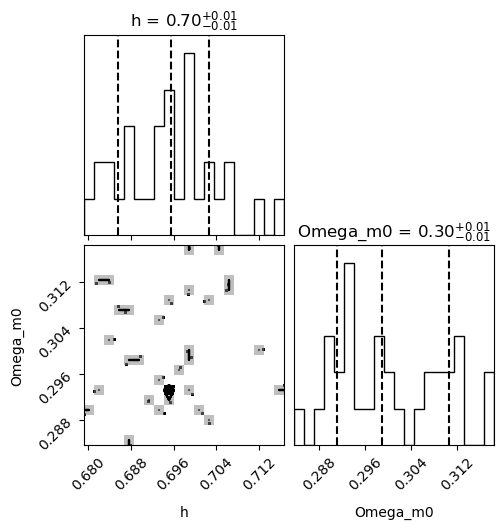

In [8]:
model_type = "LCDM"
sampler = run_mcmc(model_type = model_type)
samples, gammas,stats  = analyze_results(sampler, model_type = model_type)

print(f"Growth index gamma = {np.mean(gammas): .4f} pm {np.std(gammas): .4f}")